# 3D plot to visulize 2D error in gantry system

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
folder_path = r"C:\Users\mj.j\Documents\2025_07_28_15_33_37"

In [3]:
# load log date
log_file_name = "Log_file_2D_expansion_X_axis.csv"
# get the log file inside the folder full file path
log_file_path = os.path.join(folder_path, log_file_name)
print(log_file_path)

# check the file is avelible at the location 

if os.path.exists(log_file_path):
    print("Log file found.")
    df = pd.read_csv(log_file_path)
    # Convert the DataFrame to a NumPy array
    log_data_array = df.to_numpy()
    print(log_data_array)
else:
    print("Log file not found.")

C:\Users\mj.j\Documents\2025_07_28_15_33_37\Log_file_2D_expansion_X_axis.csv
Log file found.
[['2025-07-28-15-33-43' 0 '0.png' ... 29.0 27.8 27.3]
 ['2025-07-28-15-33-49' 0 '1.png' ... 29.0 27.8 27.3]
 ['2025-07-28-15-33-54' 0 '2.png' ... 29.0 27.8 27.3]
 ...
 ['2025-07-28-15-57-06' 0 '253.png' ... 29.0 27.8 27.4]
 ['2025-07-28-15-57-11' 0 '254.png' ... 29.0 27.8 27.4]
 ['2025-07-28-15-57-17' 0 '255.png' ... 29.0 27.8 27.4]]


# Step 1 : Plot the differance bitween calculated position and mesured encoder position

In [4]:
# load dot location matrix function
def open_3D_location_file(file_location,number_of_axis):
    array_2d = np.loadtxt(file_location, delimiter=',')
    rows_in_file,column = array_2d.shape
    calibration_data_table_row = rows_in_file//number_of_axis
    calibration_data_table_column = column
    position_np_array = np.zeros((number_of_axis,calibration_data_table_row,calibration_data_table_column))
    position_np_array = array_2d.reshape(number_of_axis,calibration_data_table_row,calibration_data_table_column)
    return position_np_array


# calculated locations file path 
calculated_dot_center_locations_file_name = "calculated_all_referance_locations.csv"
dot_center_location_file_path = os.path.join(folder_path, calculated_dot_center_locations_file_name)

# load calculated locations
number_of_axis = 3
calculated_location_numpy = open_3D_location_file(dot_center_location_file_path,number_of_axis)

# print shape
print(calculated_location_numpy.shape)



(3, 151, 151)


In [5]:
# load actual dot locations
actual_dot_locations_file_name = "Expansion_array_2D_0.csv"
actual_dot_locations_file_name = os.path.join(folder_path, actual_dot_locations_file_name)

number_of_axis = 3
actual_location_numpy = open_3D_location_file(actual_dot_locations_file_name,number_of_axis)

(225,)


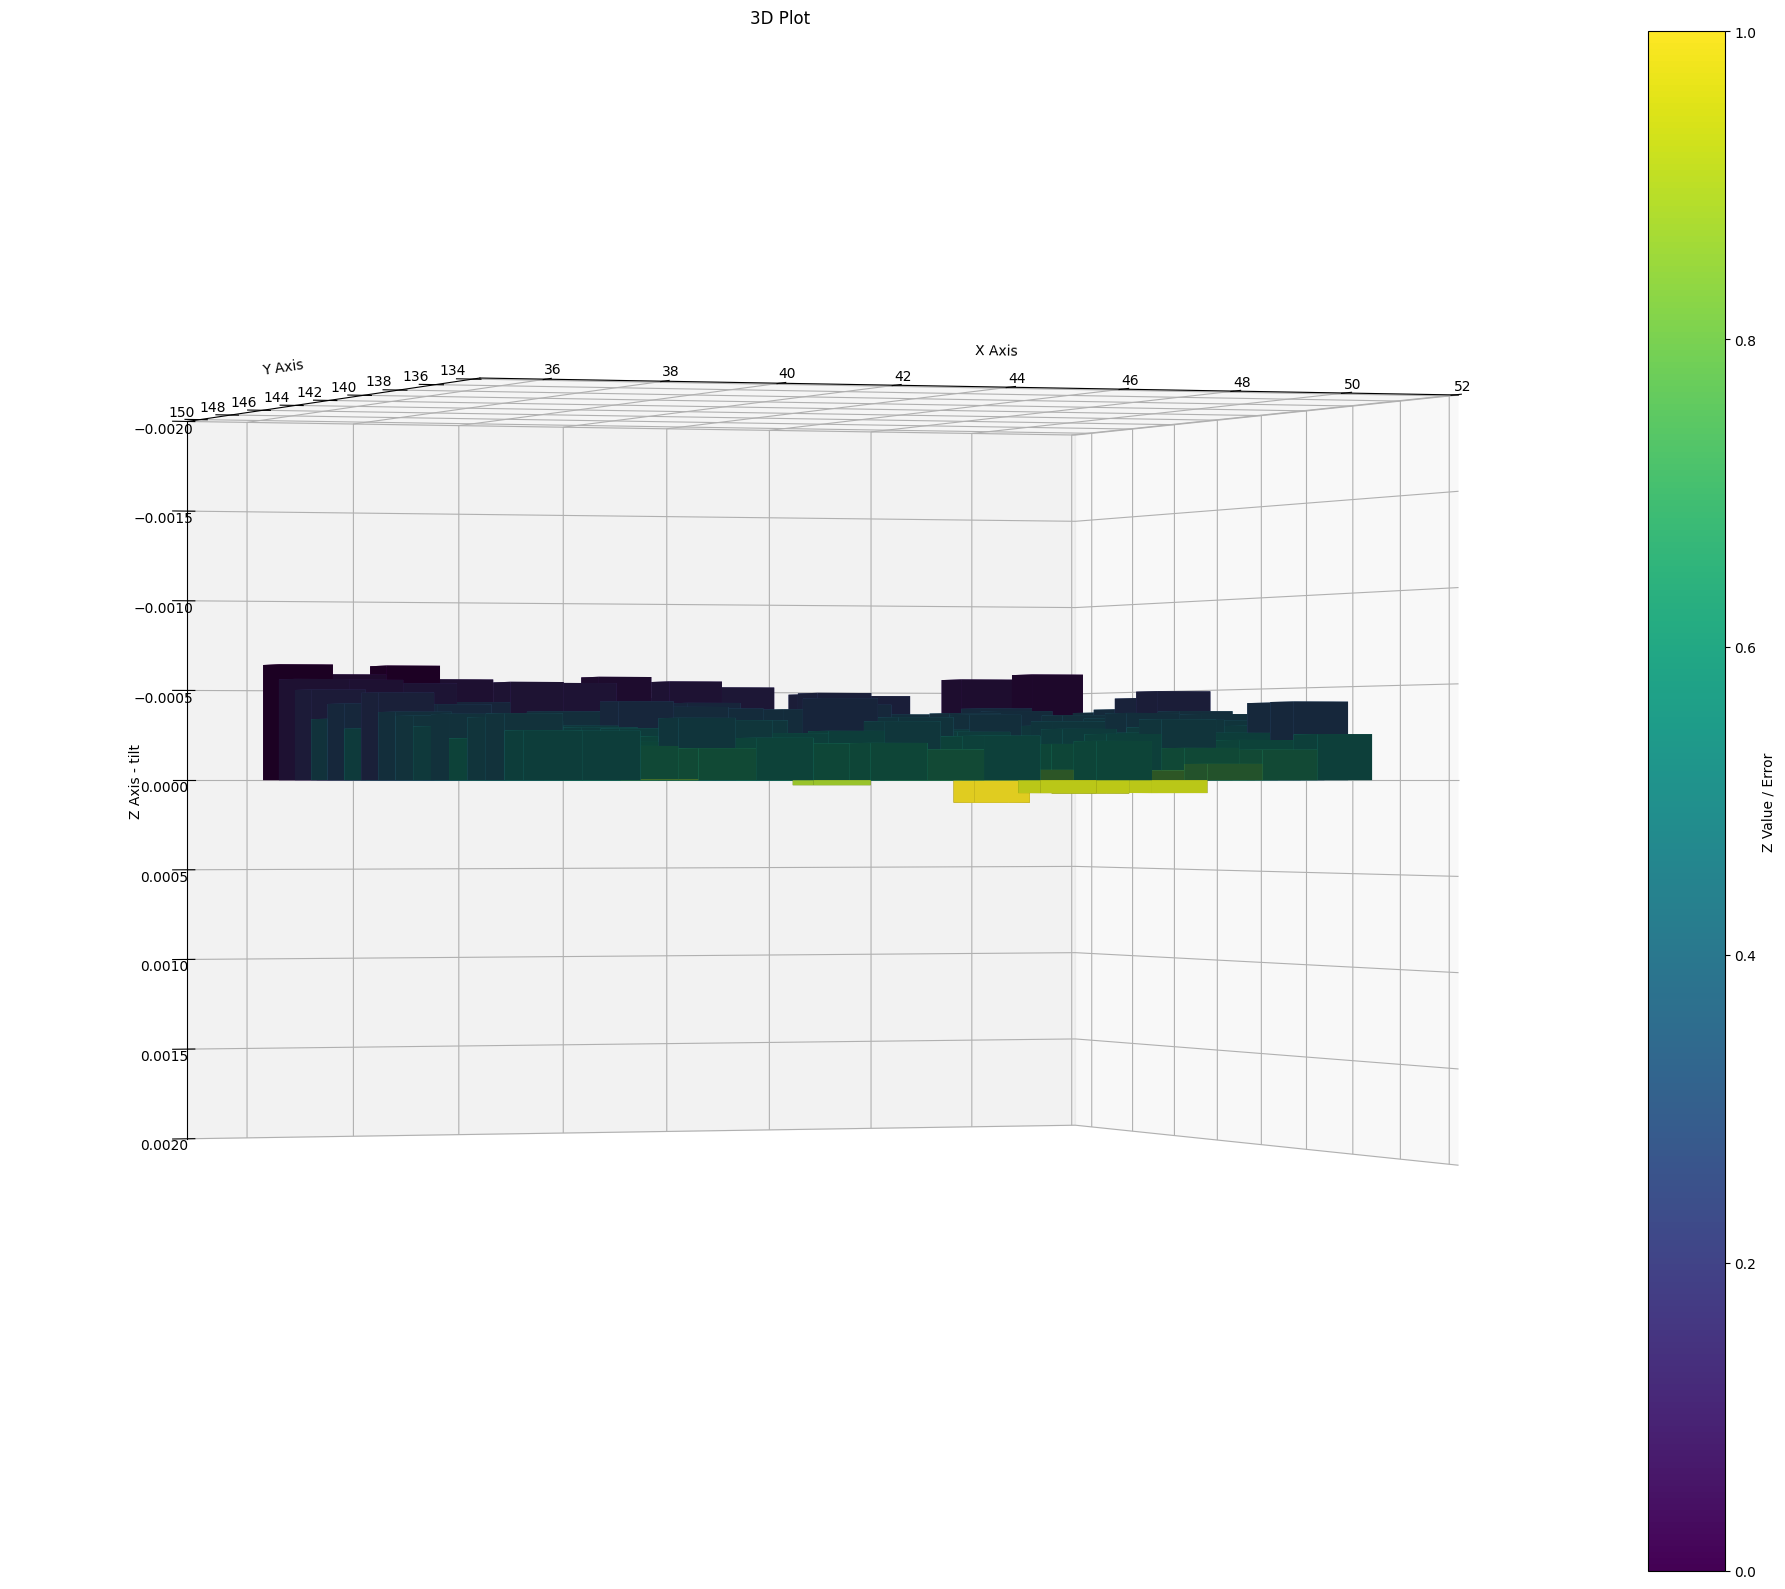

In [11]:
def plot_error_value(angle):

    # 3D plot of X, Y location and Z as position error 

    # Assuming 'calculated_location_numpy' has shape (3, rows, cols)
    # where axis 0 is for X, Y, and Z coordinates respectively.
    x_coords = calculated_location_numpy[0, :15, :15].flatten() # calculated X locations
    y_coords = calculated_location_numpy[1, :15, :15].flatten() # calculated Y locations
    z_coords = calculated_location_numpy[2, :15, :15].flatten() # This could be your glass scale tilt with respect to gantry 
    print(z_coords.shape)
    # make all the values in Z axis zeros
    z_coords = np.zeros_like(z_coords)  # perfect X and Y locations

    position_difference = actual_location_numpy[0,:15,:15] - calculated_location_numpy[0, :15, :15]
    position_difference = position_difference.flatten()

    # Create a new figure for the 3D plot
    fig = plt.figure(figsize=(20, 16))
    ax = fig.add_subplot(111, projection='3d')

    # Create the 3D scatter plot
    #scatter = ax.scatter(x_coords, y_coords, z_coords, marker='.')
    #scatter = ax.scatter(x_coords, y_coords, z_coords, c=position_difference, cmap='viridis', marker='.')
    #scatter = ax.scatter(x_coords, y_coords, z_coords, c=z_coords, cmap='viridis', marker='o')

    # Get a colormap
    cmap = plt.get_cmap('viridis')
    # Normalize the position_difference values to the range [0, 1]
    norm = plt.Normalize(position_difference.min(), position_difference.max())
    # Map the normalized values to colors
    colors = cmap(norm(position_difference))


    dx = 1  # width of bars in x direction
    dy = 1  # depth of bars in y direction
    scatter = ax.bar3d(x_coords, y_coords, z_coords, dx, dy, position_difference, color=colors)

    # Set labels for the axes
    ax.set_xlabel('X Axis')
    ax.set_ylabel('Y Axis')
    ax.set_zlabel('Z Axis - tilt')

    ax.set_zlim(0.002, -0.002)

    # Set a title for the plot
    ax.set_title('3D Plot')

    # angle = -60

    ax.view_init(elev=0, azim=angle)

    # Add a color bar which maps values to colors
    fig.colorbar(scatter, ax=ax, label='Z Value / Error')

    # Show the plot
    plt.tight_layout()
    plt.savefig(os.path.join(folder_path, f"3D_plot_XY_error_X{angle}.png"))
    plt.show()



for i in range(250, 251, 1):
    plot_error_value(i)
        


### Y axis error calculator

(225,)


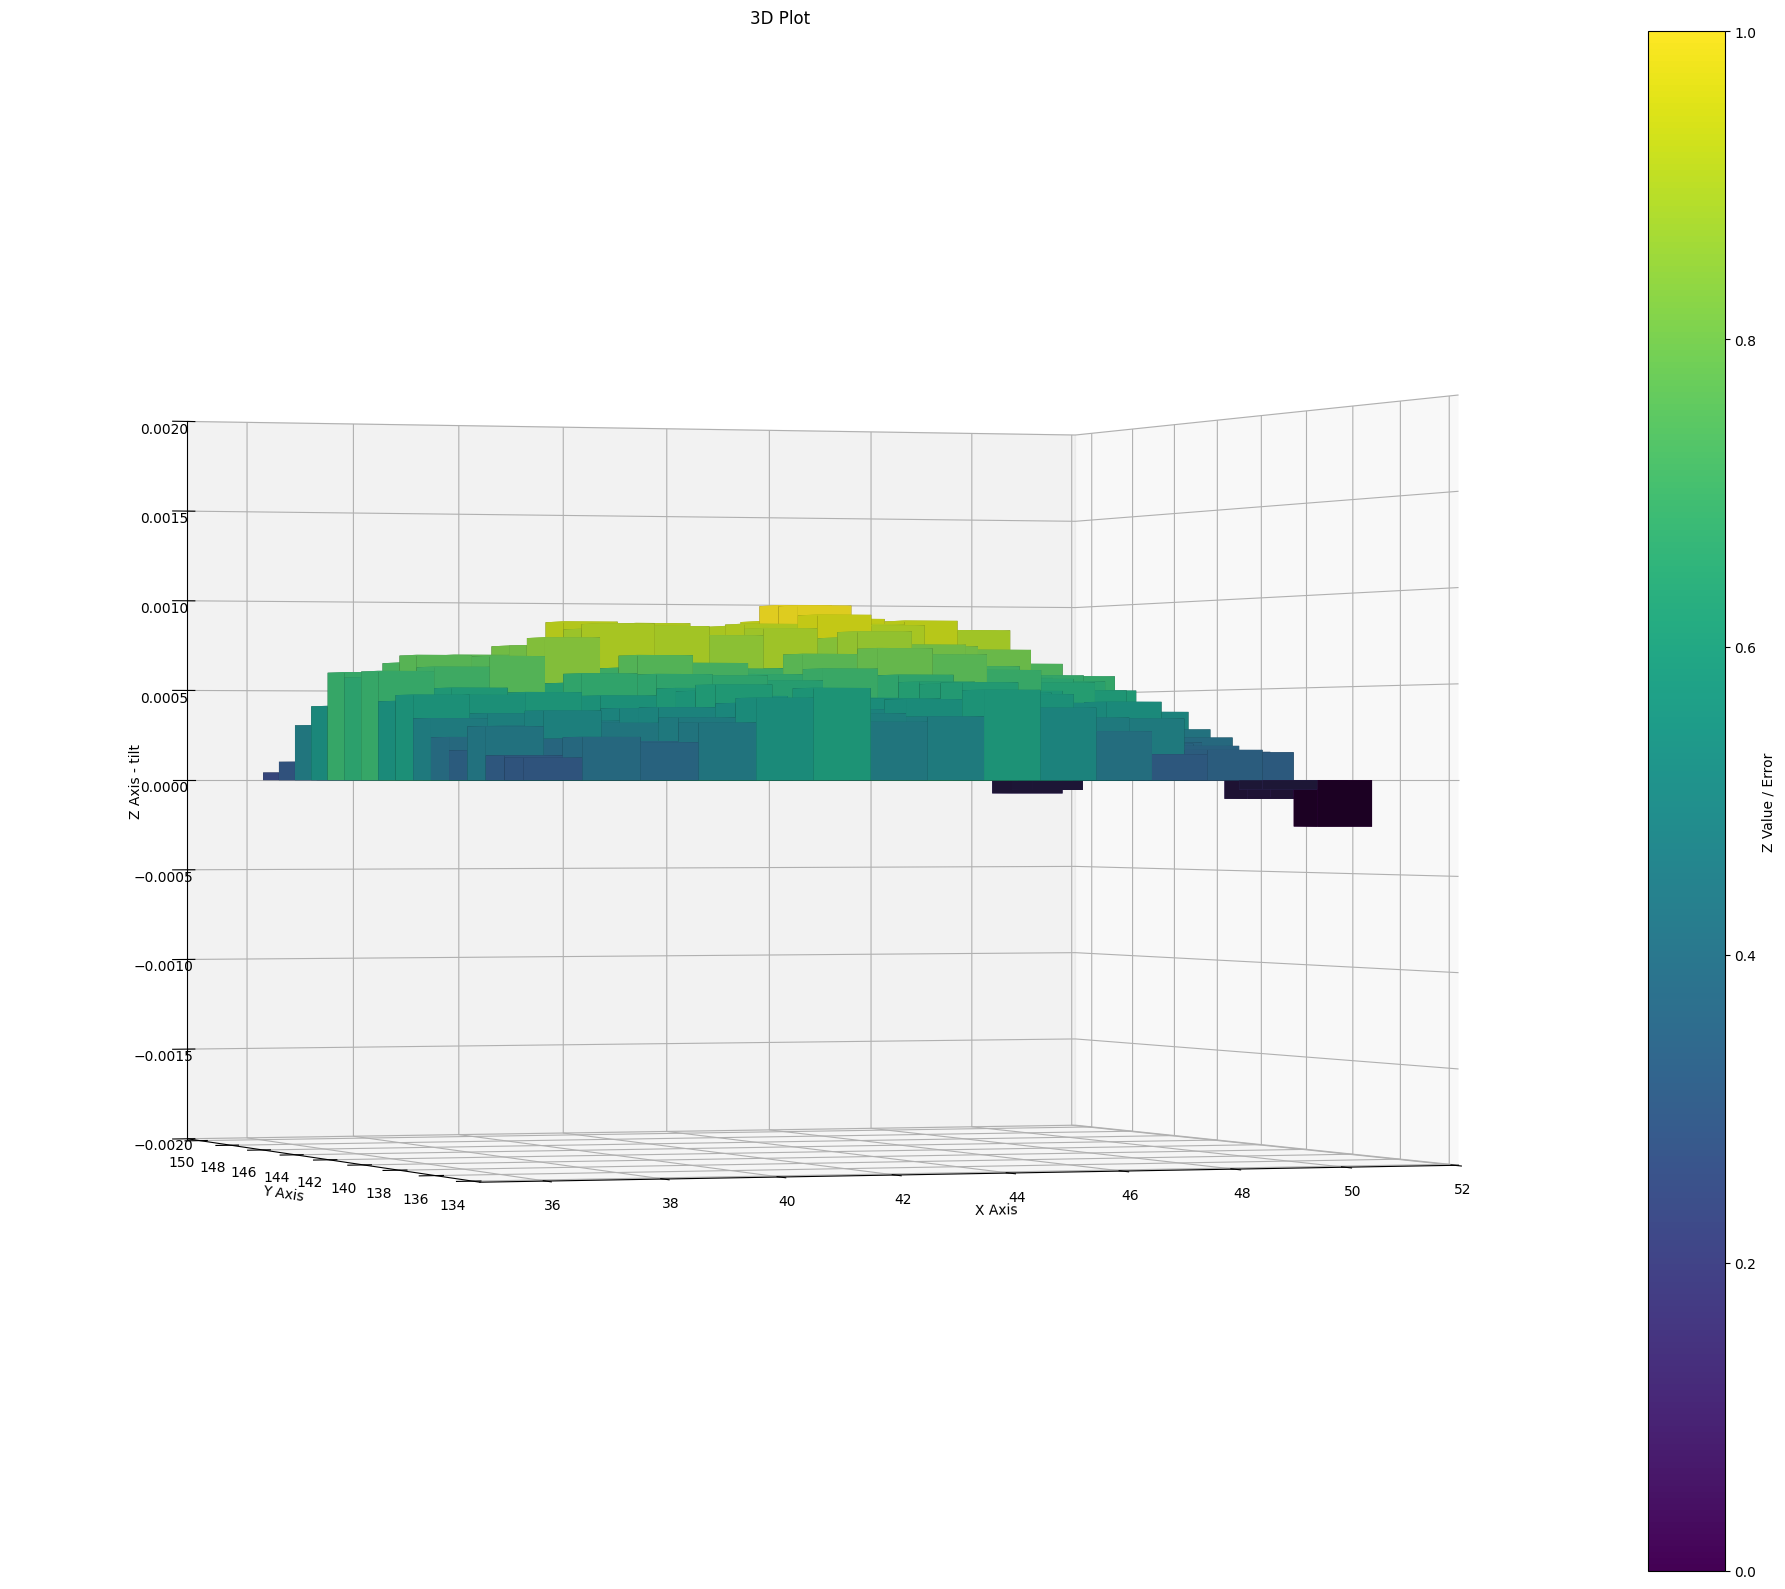

In [9]:
def plot_error_value(angle):

    # 3D plot of X, Y location and Z as position error 

    # Assuming 'calculated_location_numpy' has shape (3, rows, cols)
    # where axis 0 is for X, Y, and Z coordinates respectively.
    x_coords = calculated_location_numpy[0, :15, :15].flatten() # calculated X locations
    y_coords = calculated_location_numpy[1, :15, :15].flatten() # calculated Y locations
    z_coords = calculated_location_numpy[2, :15, :15].flatten() # This could be your glass scale tilt with respect to gantry 
    print(z_coords.shape)
    # make all the values in Z axis zeros
    z_coords = np.zeros_like(z_coords)  # perfect X and Y locations

    position_difference = actual_location_numpy[1,:15,:15] - calculated_location_numpy[1, :15, :15]
    position_difference = position_difference.flatten()

    # Create a new figure for the 3D plot
    fig = plt.figure(figsize=(20, 16))
    ax = fig.add_subplot(111, projection='3d')

    # Create the 3D scatter plot
    #scatter = ax.scatter(x_coords, y_coords, z_coords, marker='.')
    #scatter = ax.scatter(x_coords, y_coords, z_coords, c=position_difference, cmap='viridis', marker='.')
    #scatter = ax.scatter(x_coords, y_coords, z_coords, c=z_coords, cmap='viridis', marker='o')

    # Get a colormap
    cmap = plt.get_cmap('viridis')
    # Normalize the position_difference values to the range [0, 1]
    norm = plt.Normalize(position_difference.min(), position_difference.max())
    # Map the normalized values to colors
    colors = cmap(norm(position_difference))


    dx = 1  # width of bars in x direction
    dy = 1  # depth of bars in y direction
    scatter = ax.bar3d(x_coords, y_coords, z_coords, dx, dy, position_difference, color=colors)

    # Set labels for the axes
    ax.set_xlabel('X Axis')
    ax.set_ylabel('Y Axis')
    ax.set_zlabel('Z Axis - tilt')

    ax.set_zlim(-0.002, 0.002)

    # Set a title for the plot
    ax.set_title('3D Plot')

    # angle = -60

    ax.view_init(elev=0, azim=angle)

    # Add a color bar which maps values to colors
    fig.colorbar(scatter, ax=ax, label='Z Value / Error')

    # Show the plot
    plt.tight_layout()
    plt.savefig(os.path.join(folder_path, f"3D_plot_XY_error_Y{angle}.png"))
    plt.show()



for i in range(250, 251, 1):
    plot_error_value(i)

In [121]:
# Step 1 : Plot the difference between calculated position and measured encoder position

# Step 2 : Plot the difference between calculated position and vision mesured position

In [63]:
# folder path
folder_path = r"C:\Users\mj.j\Documents\2025_07_28_15_33_37"

# calculated locations file path
calculated_dot_center_locations_file_name = "calculated_all_referance_locations.csv"
dot_center_location_file_path = os.path.join(folder_path, calculated_dot_center_locations_file_name)

# load calculated locations
number_of_axis = 3
calculated_location_numpy = open_3D_location_file(dot_center_location_file_path,number_of_axis)

# print shape
print(calculated_location_numpy.shape)
print("---")

calculated_location_with_offset = calculated_location_numpy[0, :15, :15] - calculated_location_numpy[0, 0, 0]
print("calculated location with offset")
print(calculated_location_with_offset.shape)
print(calculated_location_with_offset)

print("---")

# vision rotation matrix file path
vision_rotation_matrix_file_path = "vision_rotation_matrix.csv"
vision_rotation_matrix_full_file_path = os.path.join(folder_path, vision_rotation_matrix_file_path)

# load vision rotation matrix
number_of_axis = 3
vision_rotation_matrix_numpy = open_3D_location_file(vision_rotation_matrix_full_file_path, number_of_axis)

print("vision_rotation_matrix_numpy")
print(vision_rotation_matrix_numpy.shape)
print("---")
vision_rotation_matrix_with_offset = vision_rotation_matrix_numpy[0, :15, :15] - vision_rotation_matrix_numpy[0, 0, 0]
print("vision_rotation_matrix_with_offset")
print(vision_rotation_matrix_with_offset.shape)
print(vision_rotation_matrix_with_offset)

print("---")
print("position_difference_vision")
# get diffrence of the calculated location and vision rotation matrix
position_difference_vision = vision_rotation_matrix_with_offset - calculated_location_with_offset
print(position_difference_vision.shape)
print(position_difference_vision)




(3, 151, 151)
---
calculated location with offset
(15, 15)
[[ 0.        0.99988   1.99976   2.999641  3.999521  4.999401  5.999281
   6.999161  7.999041  8.998922  9.998802 10.998682 11.998562 12.998442
  13.998323]
 [-0.000069  0.999811  1.999691  2.999571  3.999452  4.999332  5.999212
   6.999092  7.998972  8.998853  9.998733 10.998613 11.998493 12.998373
  13.998253]
 [-0.000138  0.999742  1.999622  2.999502  3.999383  4.999263  5.999143
   6.999023  7.998903  8.998783  9.998664 10.998544 11.998424 12.998304
  13.998184]
 [-0.000207  0.999673  1.999553  2.999433  3.999313  4.999194  5.999074
   6.998954  7.998834  8.998714  9.998595 10.998475 11.998355 12.998235
  13.998115]
 [-0.000276  0.999604  1.999484  2.999364  3.999244  4.999125  5.999005
   6.998885  7.998765  8.998645  9.998525 10.998406 11.998286 12.998166
  13.998046]
 [-0.000345  0.999535  1.999415  2.999295  3.999175  4.999055  5.998936
   6.998816  7.998696  8.998576  9.998456 10.998337 11.998217 12.998097
  13.997977]

In [76]:
from datetime import datetime
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
print(timestamp)

20250905_155951


(3, 151, 151)
---
calculated location with offset
(15, 15)
[[ 0.0000000e+00  9.9988000e-01  1.9997600e+00  2.9996410e+00
   3.9995210e+00  4.9994010e+00  5.9992810e+00  6.9991610e+00
   7.9990410e+00  8.9989220e+00  9.9988020e+00  1.0998682e+01
   1.1998562e+01  1.2998442e+01  1.3998323e+01]
 [-6.9000000e-05  9.9981100e-01  1.9996910e+00  2.9995710e+00
   3.9994520e+00  4.9993320e+00  5.9992120e+00  6.9990920e+00
   7.9989720e+00  8.9988530e+00  9.9987330e+00  1.0998613e+01
   1.1998493e+01  1.2998373e+01  1.3998253e+01]
 [-1.3800000e-04  9.9974200e-01  1.9996220e+00  2.9995020e+00
   3.9993830e+00  4.9992630e+00  5.9991430e+00  6.9990230e+00
   7.9989030e+00  8.9987830e+00  9.9986640e+00  1.0998544e+01
   1.1998424e+01  1.2998304e+01  1.3998184e+01]
 [-2.0700000e-04  9.9967300e-01  1.9995530e+00  2.9994330e+00
   3.9993130e+00  4.9991940e+00  5.9990740e+00  6.9989540e+00
   7.9988340e+00  8.9987140e+00  9.9985950e+00  1.0998475e+01
   1.1998355e+01  1.2998235e+01  1.3998115e+01]
 [-2.

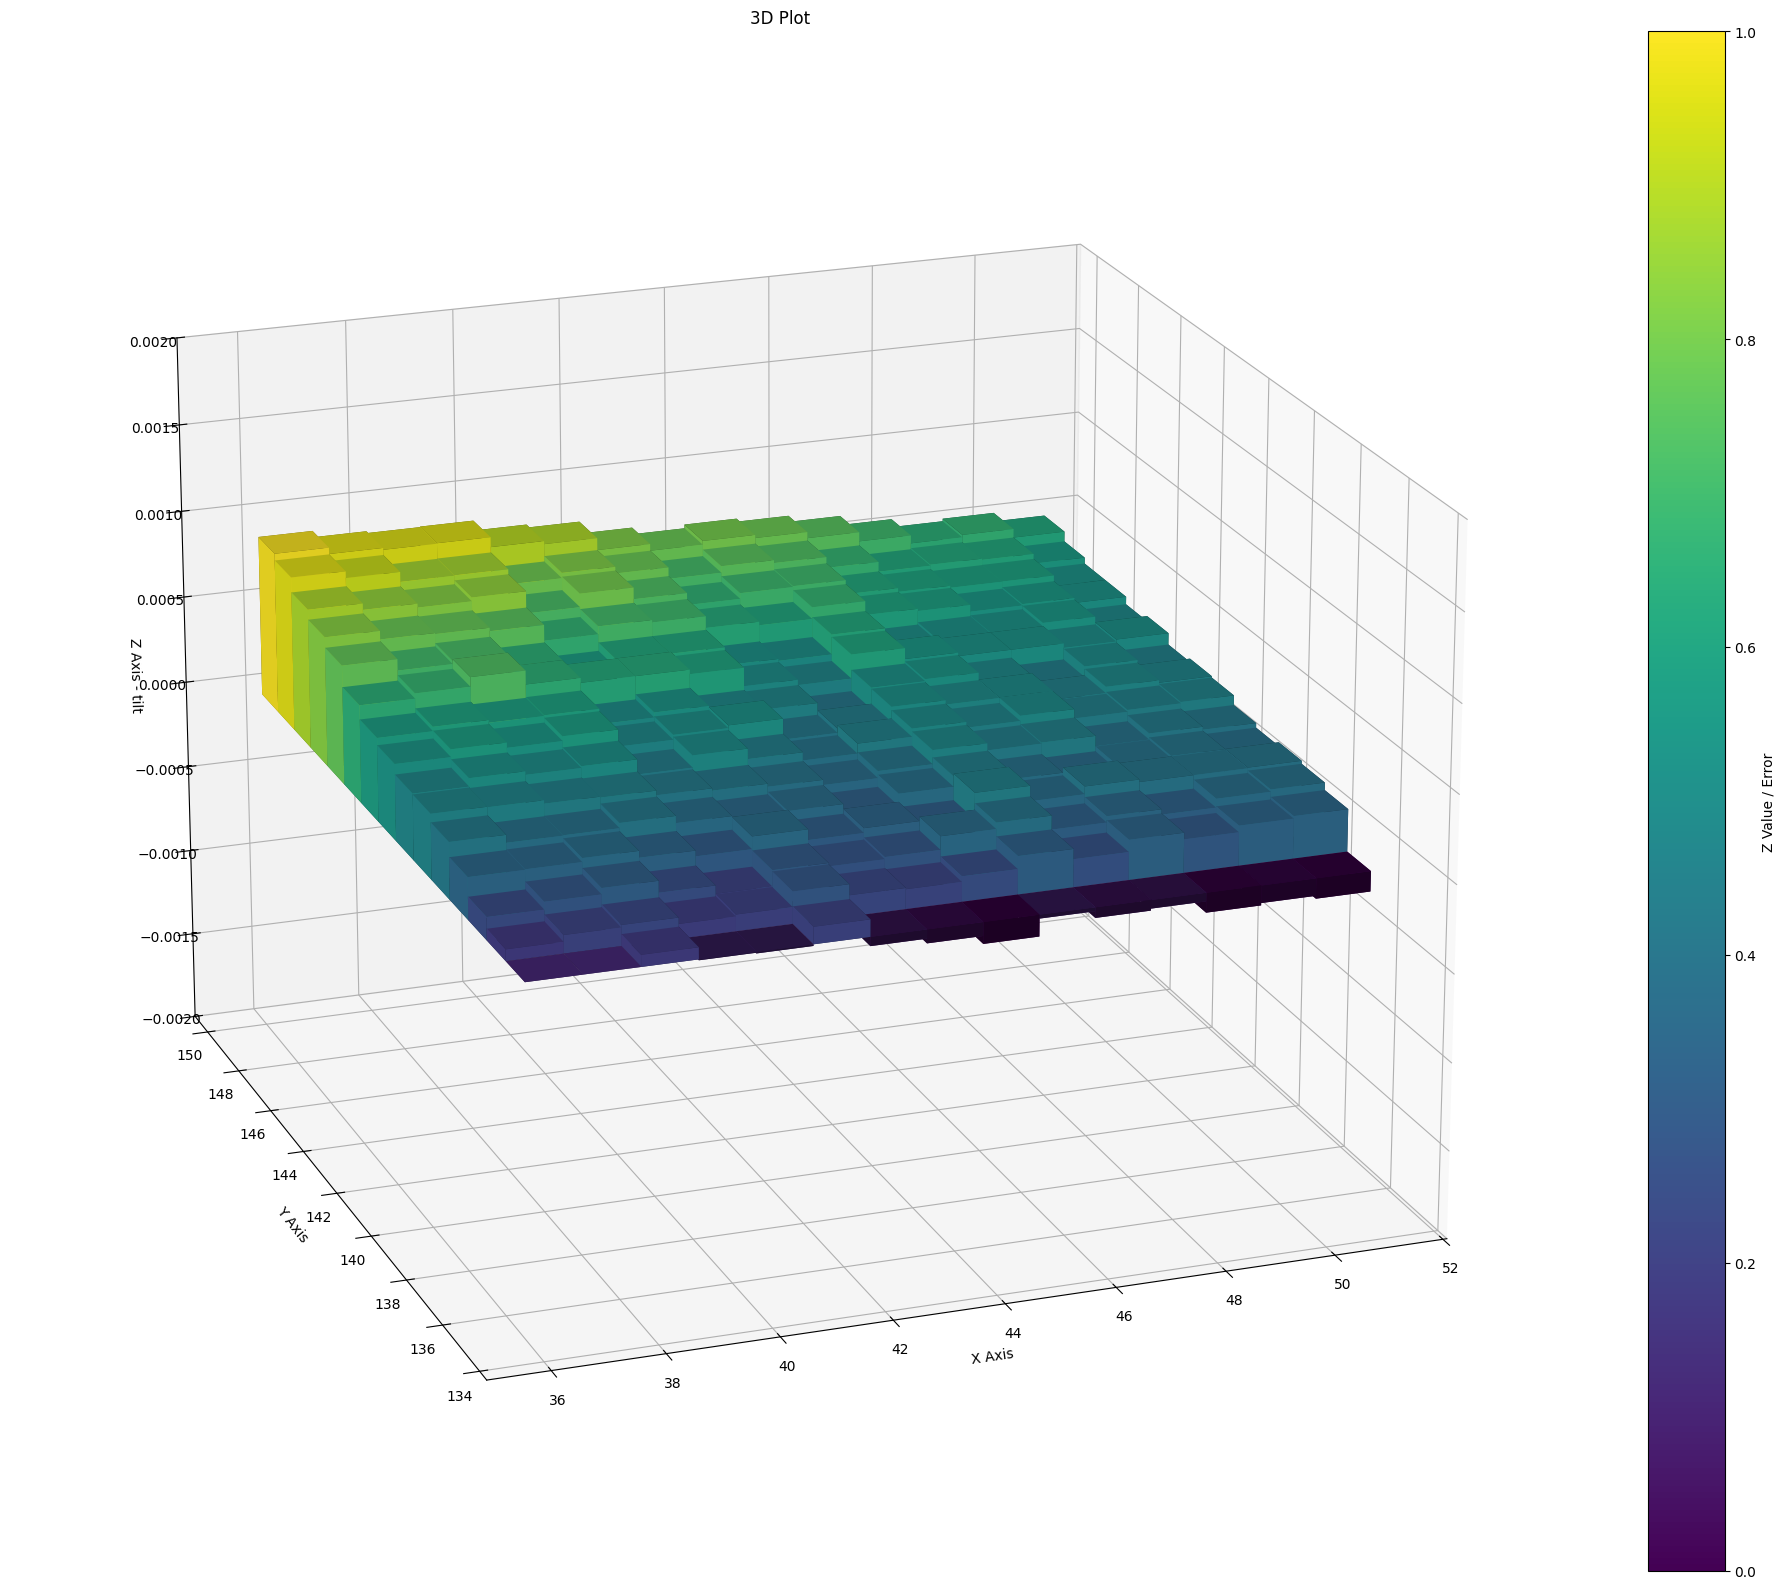

In [10]:
from datetime import datetime


def plot_error_value(angle):

    # 3D plot of X, Y location and Z as position error 

    # folder path
    folder_path = r"C:\Users\mj.j\Documents\2025_07_28_15_33_37"

    # calculated locations file path
    calculated_dot_center_locations_file_name = "calculated_all_referance_locations.csv"
    dot_center_location_file_path = os.path.join(folder_path, calculated_dot_center_locations_file_name)

    # load calculated locations
    number_of_axis = 3
    calculated_location_numpy = open_3D_location_file(dot_center_location_file_path,number_of_axis)

    # print shape
    print(calculated_location_numpy.shape)
    print("---")

    calculated_location_with_offset = calculated_location_numpy[0, :15, :15] - calculated_location_numpy[0, 0, 0]
    print("calculated location with offset")
    print(calculated_location_with_offset.shape)
    print(calculated_location_with_offset)

    print("---")

    # vision rotation matrix file path
    vision_rotation_matrix_file_path = "vision_rotation_matrix.csv"
    vision_rotation_matrix_full_file_path = os.path.join(folder_path, vision_rotation_matrix_file_path)

    # load vision rotation matrix
    number_of_axis = 3
    vision_rotation_matrix_numpy = open_3D_location_file(vision_rotation_matrix_full_file_path, number_of_axis)

    print("vision_rotation_matrix_numpy")
    print(vision_rotation_matrix_numpy.shape)
    print("---")
    vision_rotation_matrix_with_offset = vision_rotation_matrix_numpy[0, :15, :15] - vision_rotation_matrix_numpy[0, 0, 0]
    print("vision_rotation_matrix_with_offset")
    print(vision_rotation_matrix_with_offset.shape)
    print(vision_rotation_matrix_with_offset)

    print("---")
    # get diffrence of the calculated location and vision rotation matrix
    position_difference_vision = vision_rotation_matrix_with_offset - calculated_location_with_offset
    print(position_difference_vision.shape)
    print(position_difference_vision)




    # Assuming 'calculated_location_numpy' has shape (3, rows, cols)
    # where axis 0 is for X, Y, and Z coordinates respectively.
    x_coords = calculated_location_numpy[0, :15, :15].flatten() # calculated X locations
    y_coords = calculated_location_numpy[1, :15, :15].flatten() # calculated Y locations
    z_coords = calculated_location_numpy[2, :15, :15].flatten() # This could be your glass scale tilt with respect to gantry 
    print(z_coords.shape)
    # make all the values in Z axis zeros
    z_coords = np.zeros_like(z_coords)  # perfect X and Y locations

    position_difference_vision = position_difference_vision.flatten()

    # Create a new figure for the 3D plot
    fig = plt.figure(figsize=(20, 16))
    ax = fig.add_subplot(111, projection='3d')

    # Create the 3D scatter plot
    # scatter = ax.scatter(x_coords, y_coords, z_coords, marker='.')
    # scatter = ax.scatter(x_coords, y_coords, z_coords, c=position_difference, cmap='viridis', marker='.')
    # scatter = ax.scatter(x_coords, y_coords, z_coords, c=z_coords, cmap='viridis', marker='o')

    # Get a colormap
    cmap = plt.get_cmap('viridis')
    # Normalize the position_difference values to the range [0, 1]
    norm = plt.Normalize(position_difference_vision.min(), position_difference_vision.max())
    # Map the normalized values to colors
    colors = cmap(norm(position_difference_vision))

    dx = 1  # width of bars in x direction
    dy = 1  # depth of bars in y direction
    #scatter = ax.bar3d(x_coords, y_coords, z_coords, dx, dy, z_coords, color=colors)
    scatter = ax.bar3d(x_coords, y_coords, z_coords, dx, dy, position_difference_vision, color=colors)

    # Set labels for the axes
    ax.set_xlabel('X Axis')
    ax.set_ylabel('Y Axis')
    ax.set_zlabel('Z Axis - tilt')

    ax.set_zlim(-0.002, 0.002)

    # Set a title for the plot
    ax.set_title('3D Plot')

    # angle = -60

    ax.view_init(elev=20, azim=angle)

    # Add a color bar which maps values to colors
    fig.colorbar(scatter, ax=ax, label='Z Value / Error')

    # get time stamp now
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    print(timestamp)

    #get pixel to mm from active recipe file
    active_recipe_file_path = r"C:\Users\mj.j\Documents\2D_optical_vision_mapping\src\recipes\active_recipe.csv"
    df_active_recipe = pd.read_csv(active_recipe_file_path)
    pixel_to_mm = df_active_recipe.loc[df_active_recipe['parameter'] == 'pixel_to_mm', 'value'].values[0]
    pixel_to_mm = float(pixel_to_mm)
    print(f"pixel_to_mm: {pixel_to_mm}")
    
    # Show the plot
    plt.tight_layout()
    plt.savefig(os.path.join(folder_path, f"3D_plot_XY_error_{angle}_{pixel_to_mm}_{timestamp}.png"))
    plt.show()



for i in range(250, 251, 1):
    plot_error_value(i)
        


(3, 151, 151)
---
calculated location with offset
(15, 15)
[[ 0.        0.000093  0.000186  0.00028   0.000373  0.000466  0.000559
   0.000653  0.000746  0.000839  0.000932  0.001025  0.001119  0.001212
   0.001305]
 [ 1.000043  1.000136  1.000229  1.000323  1.000416  1.000509  1.000602
   1.000696  1.000789  1.000882  1.000975  1.001068  1.001162  1.001255
   1.001348]
 [ 2.000086  2.000179  2.000272  2.000366  2.000459  2.000552  2.000645
   2.000739  2.000832  2.000925  2.001018  2.001111  2.001205  2.001298
   2.001391]
 [ 3.000129  3.000222  3.000315  3.000409  3.000502  3.000595  3.000688
   3.000782  3.000875  3.000968  3.001061  3.001154  3.001248  3.001341
   3.001434]
 [ 4.000172  4.000265  4.000358  4.000452  4.000545  4.000638  4.000731
   4.000824  4.000918  4.001011  4.001104  4.001197  4.001291  4.001384
   4.001477]
 [ 5.000215  5.000308  5.000401  5.000495  5.000588  5.000681  5.000774
   5.000867  5.000961  5.001054  5.001147  5.00124   5.001334  5.001427
   5.00152 ]

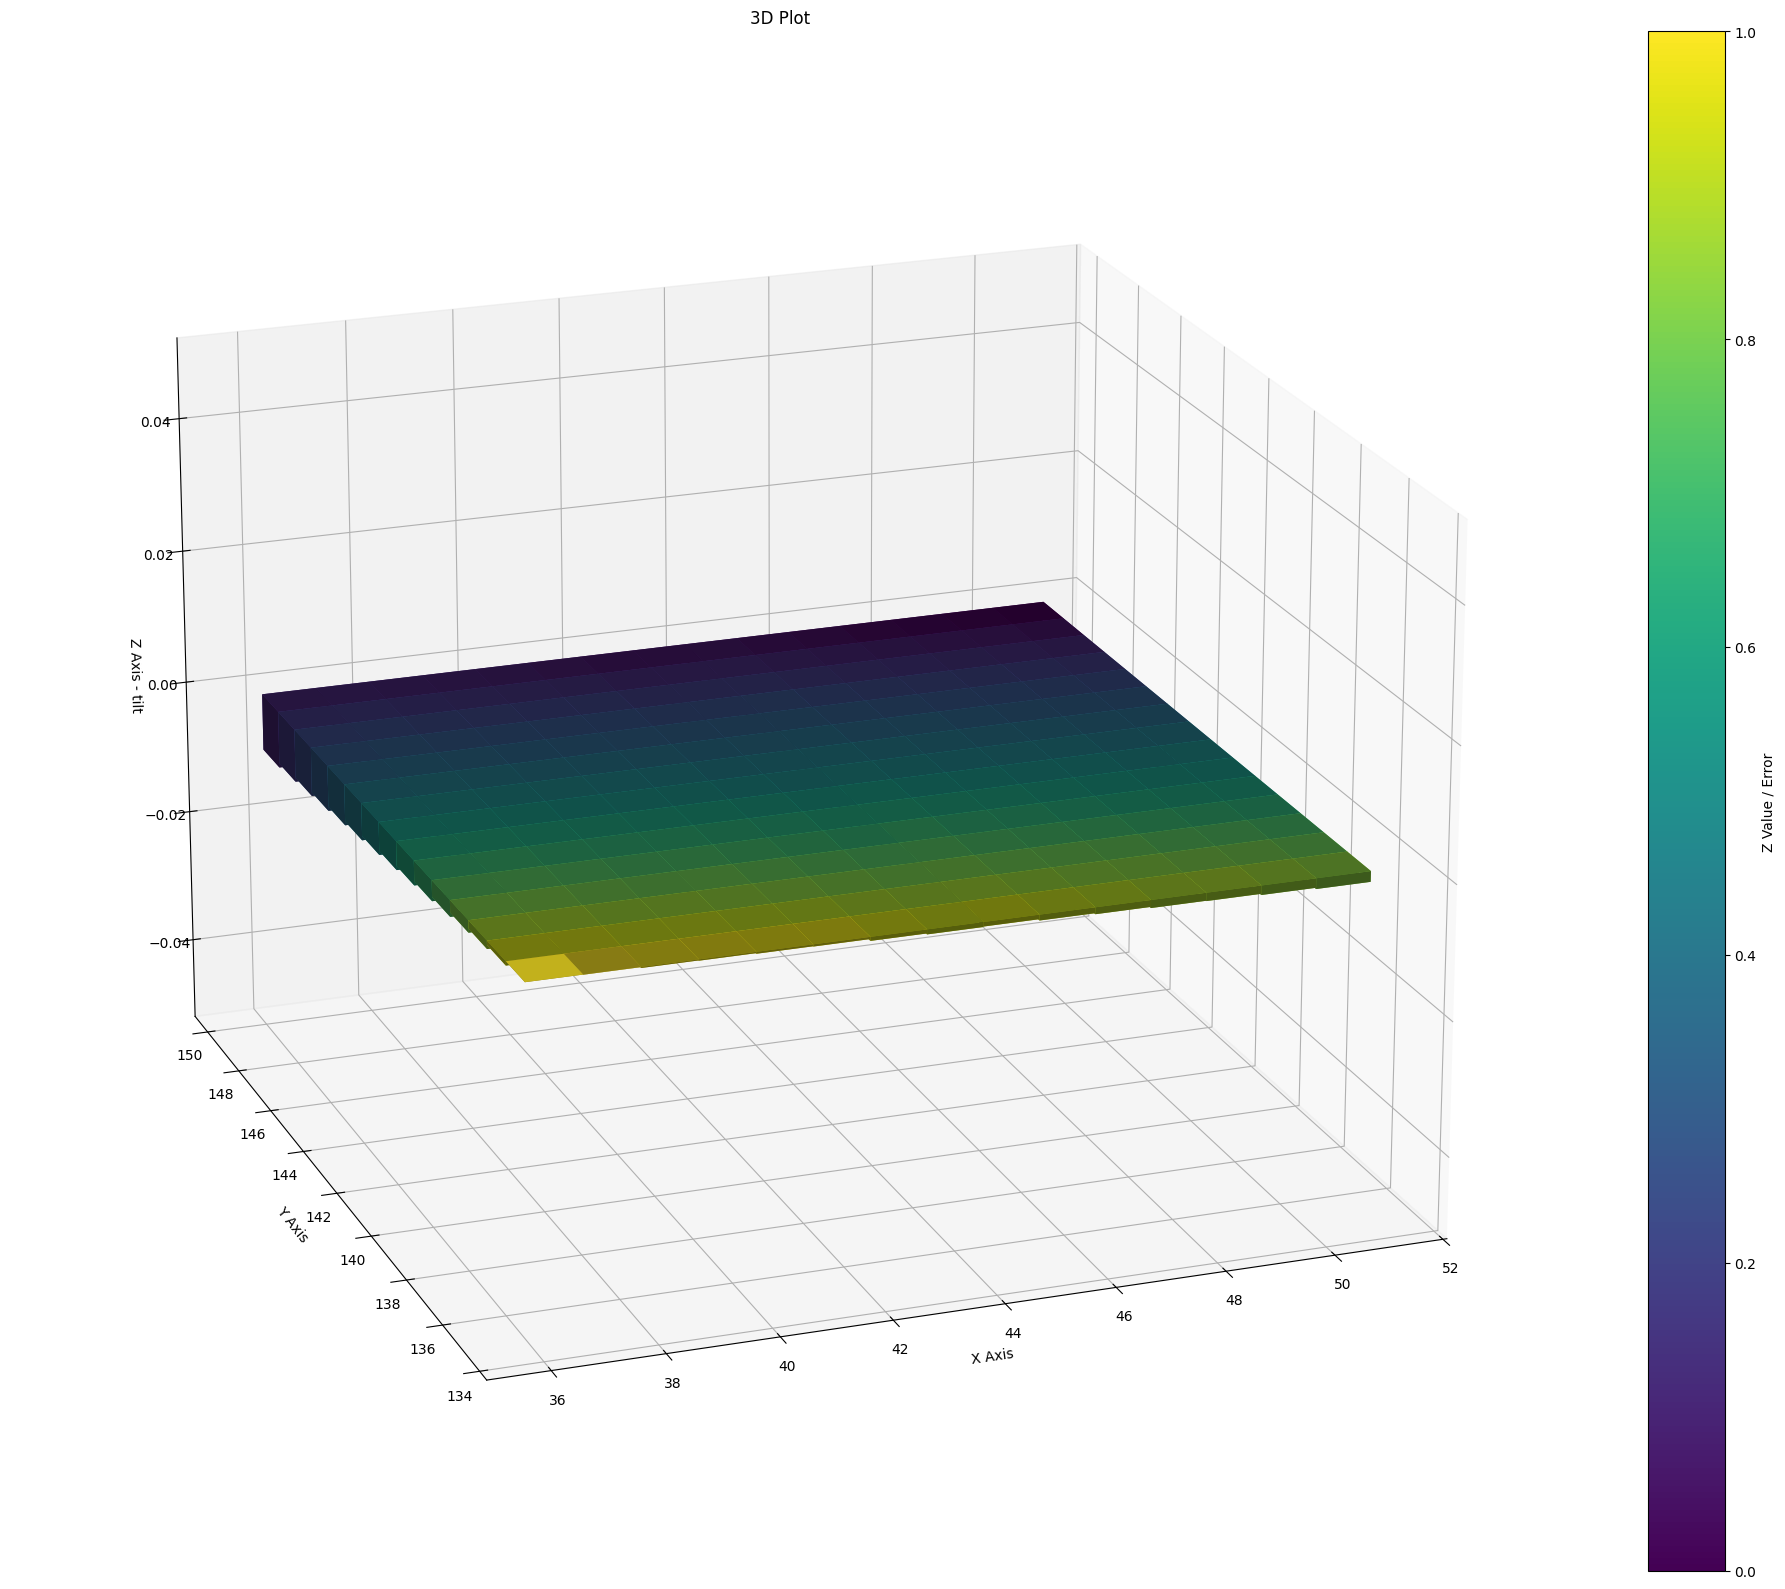

In [99]:
from datetime import datetime


def plot_error_value(angle):

    # 3D plot of X, Y location and Z as position error 

    # folder path
    folder_path = r"C:\Users\mj.j\Documents\2025_07_28_15_33_37"

    # calculated locations file path
    calculated_dot_center_locations_file_name = "calculated_all_referance_locations.csv"
    dot_center_location_file_path = os.path.join(folder_path, calculated_dot_center_locations_file_name)

    # load calculated locations
    number_of_axis = 3
    calculated_location_numpy = open_3D_location_file(dot_center_location_file_path,number_of_axis)

    # print shape
    print(calculated_location_numpy.shape)
    print("---")

    calculated_location_with_offset = calculated_location_numpy[1, :15, :15] - calculated_location_numpy[1, 0, 0]
    print("calculated location with offset")
    print(calculated_location_with_offset.shape)
    print(calculated_location_with_offset)

    print("---")

    # vision rotation matrix file path
    vision_rotation_matrix_file_path = "vision_rotation_matrix.csv"
    vision_rotation_matrix_full_file_path = os.path.join(folder_path, vision_rotation_matrix_file_path)

    # load vision rotation matrix
    number_of_axis = 3
    vision_rotation_matrix_numpy = open_3D_location_file(vision_rotation_matrix_full_file_path, number_of_axis)

    print("vision_rotation_matrix_numpy")
    print(vision_rotation_matrix_numpy.shape)
    print("---")
    vision_rotation_matrix_with_offset = vision_rotation_matrix_numpy[1, :15, :15] - vision_rotation_matrix_numpy[1, 0, 0]
    print("vision_rotation_matrix_with_offset")
    print(vision_rotation_matrix_with_offset.shape)
    print(vision_rotation_matrix_with_offset)

    print("---")
    # get diffrence of the calculated location and vision rotation matrix
    position_difference_vision = vision_rotation_matrix_with_offset - calculated_location_with_offset
    print(position_difference_vision.shape)
    print(position_difference_vision)




    # Assuming 'calculated_location_numpy' has shape (3, rows, cols)
    # where axis 0 is for X, Y, and Z coordinates respectively.
    x_coords = calculated_location_numpy[0, :15, :15].flatten() # calculated X locations
    y_coords = calculated_location_numpy[1, :15, :15].flatten() # calculated Y locations
    z_coords = calculated_location_numpy[2, :15, :15].flatten() # This could be your glass scale tilt with respect to gantry 
    print(z_coords.shape)
    # make all the values in Z axis zeros
    z_coords = np.zeros_like(z_coords)  # perfect X and Y locations

    position_difference_vision = position_difference_vision.flatten()

    # Create a new figure for the 3D plot
    fig = plt.figure(figsize=(20, 16))
    ax = fig.add_subplot(111, projection='3d')

    # Create the 3D scatter plot
    # scatter = ax.scatter(x_coords, y_coords, z_coords, marker='.')
    # scatter = ax.scatter(x_coords, y_coords, z_coords, c=position_difference, cmap='viridis', marker='.')
    # scatter = ax.scatter(x_coords, y_coords, z_coords, c=z_coords, cmap='viridis', marker='o')

    # Get a colormap
    cmap = plt.get_cmap('viridis')
    # Normalize the position_difference values to the range [0, 1]
    norm = plt.Normalize(position_difference_vision.min(), position_difference_vision.max())
    # Map the normalized values to colors
    colors = cmap(norm(position_difference_vision))

    dx = 1  # width of bars in x direction
    dy = 1  # depth of bars in y direction
    #scatter = ax.bar3d(x_coords, y_coords, z_coords, dx, dy, z_coords, color=colors)
    scatter = ax.bar3d(x_coords, y_coords, z_coords, dx, dy, position_difference_vision, color=colors)

    # Set labels for the axes
    ax.set_xlabel('X Axis')
    ax.set_ylabel('Y Axis')
    ax.set_zlabel('Z Axis - tilt')

    #ax.set_zlim(-0.002, 0.002)

    # Set a title for the plot
    ax.set_title('3D Plot')

    # angle = -60

    ax.view_init(elev=20, azim=angle)

    # Add a color bar which maps values to colors
    fig.colorbar(scatter, ax=ax, label='Z Value / Error')

    # get time stamp now
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    print(timestamp)

    #get pixel to mm from active recipe file
    active_recipe_file_path = r"C:\Users\mj.j\Documents\2D_optical_vision_mapping\src\recipes\active_recipe.csv"
    df_active_recipe = pd.read_csv(active_recipe_file_path)
    pixel_to_mm = df_active_recipe.loc[df_active_recipe['parameter'] == 'pixel_to_mm', 'value'].values[0]
    pixel_to_mm = float(pixel_to_mm)
    print(f"pixel_to_mm: {pixel_to_mm}")
    
    # Show the plot
    plt.tight_layout()
    plt.savefig(os.path.join(folder_path, f"3D_plot_XY_error_{angle}_{pixel_to_mm}_{timestamp}.png"))
    plt.show()



for i in range(250, 251, 1):
    plot_error_value(i)
